<a href="https://colab.research.google.com/github/cedizen/wine_store_sales/blob/main/project_bottleneck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Bottleneck - Data analysis for a wine store**

This project aims to perform a comprehensive data analysis for a wine store called 'Bottle-neck'. The main objective is to identify key sales metrics, understand product performance, analyze inventory levels, and uncover potential bottlenecks or opportunities within the business. We will be working with three main datasets:

*   **ERP Data**: Contains information about product pricing, stock quantities, and purchase prices.
*   **Liaison Data**: Acts as a bridge between the ERP and Web data, linking product IDs to their web counterparts.
*   **Web Data**: Includes details on total sales, product types, and other web-specific metrics.

# **Imports**

This section imports all necessary Python libraries for data manipulation, numerical operations, visualization, and statistical analysis. We use `pandas` for data handling, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for plotting, and `scipy.stats.spearmanr` for correlation testing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import spearmanr
from scipy.stats import levene
from scipy.stats import kruskal, f_oneway

# **Functions**

This section defines several custom utility functions designed to streamline common data analysis tasks. These functions will be reused throughout the notebook for checking nulls, duplicates, inspecting data, and generating various plots, ensuring consistency and efficiency in our analysis workflow.

In [ ]:
def check_nulls(df, col=None):
  """Checks for null values in a DataFrame or a specific column.

  Args:
    df (pd.DataFrame): The DataFrame to check.
    col (str, optional): The name of the column to check. If None, checks all columns.

  Returns:
    pd.Series or int: A Series with the count of null values per column, or the count for a specific column.
  """
  if col is not None:
     return df[col].isnull().sum()
  return df.isnull().sum()

def check_duplicates(df):
  """Checks for duplicated rows in a DataFrame.

  Args:
    df (pd.DataFrame): The DataFrame to check.

  Returns:
    int: The number of duplicated rows.
  """
  return df.duplicated().sum()

def show_data(col):
  """Shows the value counts for a given Series (column).

  Args:
    col (pd.Series): The Series for which to show value counts.

  Returns:
    pd.Series: A Series containing counts of unique values.
  """
  return col.value_counts()

def initialize_df(df):
  """Displays the info and head of a DataFrame.

  Args:
    df (pd.DataFrame): The DataFrame to initialize and inspect.
  """
  info = df.info()
  head = df.head()
  display(info, head)

def pairplot(df, cols=None, title=None):
  """Generates a pair plot for specified columns in a DataFrame.

  Args:
    df (pd.DataFrame): The DataFrame to plot.
    cols (list, optional): A list of column names to include in the pair plot. If None, all numeric columns are used.
    title (str, optional): The title of the plot.
  """
  g = sns.pairplot(df, vars=cols, corner=True)
  g.fig.suptitle=title

def boxplot(df, cols, x=None, title=None):
  """Generates a box plot for specified columns in a DataFrame.

  Args:
    df (pd.DataFrame): The DataFrame to plot.
    cols (list or str): The column(s) to plot.
    x (str, optional): The column to use for the x-axis if plotting multiple box plots.
    title (str, optional): The title of the plot.

  Returns:
    matplotlib.axes.Axes: The Axes object containing the plot.
  """
  df[cols].plot(
    kind="box")
  plt.title("title")
  plt.show()

def check_negative_values(df, cols):
  """Checks for negative values in specified columns of a DataFrame.

  Args:
    df (pd.DataFrame): The DataFrame to check.
    cols (list): A list of column names to check for negative values.

  Returns:
    pd.DataFrame: A DataFrame containing rows where any of the specified columns have negative values.
  """
  return df[(df[cols] < 0).any(axis=1)]

def groupby_feature(df, grouped_feature, metrics, agg_features=None):
  """Groups a DataFrame by a specified feature and applies aggregation metrics.

  Args:
    df (pd.DataFrame): The DataFrame to group.
    grouped_feature (str or list): The column(s) to group by.
    metrics (dict or list): The aggregation metrics to apply. Can be a dictionary of column-to-aggregation-function mappings or a list of aggregation functions.
    agg_features (list, optional): A list of columns to aggregate. If None, metrics are applied to all non-grouped columns.

  Returns:
    pd.DataFrame: The aggregated DataFrame.
  """
  if agg_features is None:
    return df.groupby(grouped_feature, as_index=False).agg(metrics)
  else:
    return df.groupby(grouped_feature, as_index=False)[agg_features].agg(metrics)

def sort_values(df, columns_to_sort, direction, top_n=None):
  """Sorts a DataFrame by specified columns and returns the top N rows if requested.

  Args:
    df (pd.DataFrame): The DataFrame to sort.
    columns_to_sort (str or list): The column(s) to sort by.
    direction (bool): True for ascending, False for descending.
    top_n (int, optional): The number of top rows to return. If None, returns the entire sorted DataFrame.

  Returns:
    pd.DataFrame: The sorted DataFrame, optionally truncated to top_n rows.
  """
  if top_n is None:
    return df.sort_values(columns_to_sort, ascending=direction)
  else:
    return df.sort_values(columns_to_sort, ascending=direction).head(top_n)

def plot_bar(df,
             colX,
             colY,
             title,
             xlabel=None,
             ylabel=None,
             legend=None,
             ax=None):
    """Generates a bar plot from a DataFrame.

    Args:
      df (pd.DataFrame): The DataFrame to plot.
      colX (str): The column name for the x-axis.
      colY (str): The column name for the y-axis.
      title (str): The title of the plot.
      xlabel (str, optional): The label for the x-axis. Defaults to colX.
      ylabel (str, optional): The label for the y-axis. Defaults to colY.
      ax (matplotlib.axes.Axes, optional): The Axes object to plot on. If None, a new one is created.

    Returns:
      matplotlib.axes.Axes: The Axes object containing the plot.
    """
    ax= df.plot(
        kind="bar",
        x=colX,
        y=colY,
        legend=legend,
        ax=ax
    )

    if xlabel is None:
      ax.set_xlabel(xlabel)

    if ylabel is None:
      ax.set_ylabel(ylabel)

    ax.set_title(title)
    return ax

In [ ]:
def loading_file(init, file):
  path = init["path"]
  ext = init["ext"]
  df = pd.read_excel(f"{path}{file}{ext}")
  return df

In [ ]:
def IQR(serie):
  Q1 = serie.quantile(0.25)
  Q3 = serie.quantile(0.75)
  iqr = Q3 - Q1
  return iqr

In [ ]:
def detect_outliers(serie, multiplicator=1.5):
  iqr = IQR(serie)

  upper_bound = serie.quantile(0.75) + multiplicator * iqr
  lower_bound = serie.quantile(0.25) - multiplicator * iqr

  outliers = (serie > upper_bound) | (serie < lower_bound)

  return outliers

# **Data preloading**

This section defines the file paths and extensions for the datasets, and then loads them into pandas DataFrames. It's a crucial first step to get the raw data into our working environment for further processing.

Here, the three main datasets (`erp`, `liaison`, and `web`) are loaded into their respective DataFrames: `df_erp`, `df_liaison`, and `df_web`. The `UserWarning` regarding 'Unknown extension' from `openpyxl` can often be ignored as long as the data loads correctly.

Initialisation

In [ ]:
init = {
  "path": "data/",
  "ext":".xlsx"
}

In [ ]:
files = {
  "file_erp": "erp",
  "file_liaison": "liaison",
  "file_web": "web",
}

In [ ]:
df_erp = loading_file(init, files["file_erp"])
df_liaison = loading_file(init, files["file_liaison"])
df_web = loading_file(init, files["file_web"])

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


The `loading_file` function is a utility to simplify loading data from Excel files. It takes the path, filename, extension, and an optional separator, returning a pandas DataFrame. This function helps maintain consistency in how data files are read.

# **Data checking and loading**

This section focuses on the initial loading, inspection, and cleaning of the raw datasets. Each dataset (ERP, Liaison, Web) will be processed individually to ensure data quality and prepare them for merging. Steps include checking data types, identifying and handling null values, and addressing duplicates or inconsistencies.

## **ERP dataset**

This section details the exploration and cleaning of the ERP (Enterprise Resource Planning) dataset (`df_erp`). This dataset contains core product information, including prices, stock levels, and purchase costs. Our goal is to ensure its integrity and consistency before merging it with other data sources.

Initialisation

We start by initializing and inspecting the `df_erp` DataFrame. This involves displaying its information (data types, non-null counts) and the first few rows to get a quick overview of its structure and content.

In [ ]:
initialize_df(df_erp)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


None

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


All values appear to have the correct data types. The absence of 'object' type for numeric columns (except where expected, e.g., `stock_status`) indicates that numerical data is properly formatted and does not contain unexpected strings or mixed types, which simplifies subsequent analyses.

Check null values

It's crucial to identify any missing values in the dataset. Null values can impact the accuracy of our analysis and models. This step helps us understand data completeness and decide on appropriate handling strategies, such as imputation or removal.

In [ ]:
null_values = check_nulls(df_erp)
null_values

,0
product_id,0
onsale_web,0
price,0
stock_quantity,0
stock_status,0
purchase_price,0


Check duplicated values

Detecting duplicate rows is essential for data integrity. Duplicates can skew results, especially in aggregations and statistical tests. This step ensures each observation is unique, preventing overcounting or biased analyses.

In [ ]:
duplicated_values = check_duplicates(df_erp)
duplicated_values

np.int64(0)

In [ ]:
for col in df_erp.columns:
  data = show_data(df_erp[col])
  display(data)

,count
product_id,
7338,1
3847,1
3849,1
3850,1
4032,1
...,...
4049,1
4048,1
4047,1


,count
onsale_web,
1,716
0,109


,count
price,
45.0,15
31.0,13
19.0,9
13.5,8
40.0,8
...,...
31.2,1
32.7,1
50.5,1


,count
stock_quantity,
0,90
7,32
23,30
12,29
5,27
...,...
138,1
68,1
58,1


,count
stock_status,
instock,733
outofstock,92


,count
purchase_price,
8.00,4
16.02,4
13.67,4
10.31,4
5.64,4
...,...
7.81,1
17.14,1
8.68,1


After checking the value counts for each column in the `df_erp` DataFrame, we can confirm the distribution of unique entries. This helps in understanding the diversity and consistency of data within each feature, such as the range of product IDs, the binary nature of 'onsale_web', and the different price points.

Distribution of prices

In [ ]:
prices_columns = ["purchase_price", "price"]

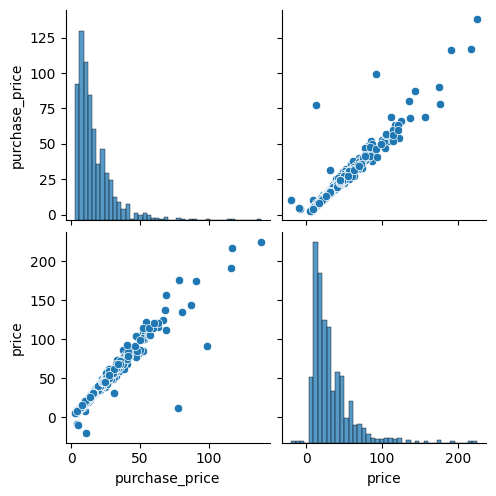

In [ ]:
sns.pairplot(df_erp[prices_columns])
plt.show()

Price and purchase are correlated. But price and purchase price are left_skewed, that means there are outliers.

Let's review it with a boxplot

Based on the previous boxplots, some outliers are observed and need to be treated in order to better know if it parts of the company strategy or simple errors

In [ ]:
outliers_price = detect_outliers(df_erp["price"])
extreme_outliers_price = detect_outliers(df_erp["price"], multiplicator=3)

In [ ]:
outliers_purchase_price = detect_outliers(df_erp["purchase_price"])
extreme_outliers_purchase_price = detect_outliers(df_erp["purchase_price"], multiplicator=3)

In [ ]:
df_outliers_price_purchase = df_erp.loc[outliers_price & outliers_purchase_price, prices_columns]
df_extreme_outliers_price_purchase = df_erp.loc[extreme_outliers_price & extreme_outliers_purchase_price, prices_columns]

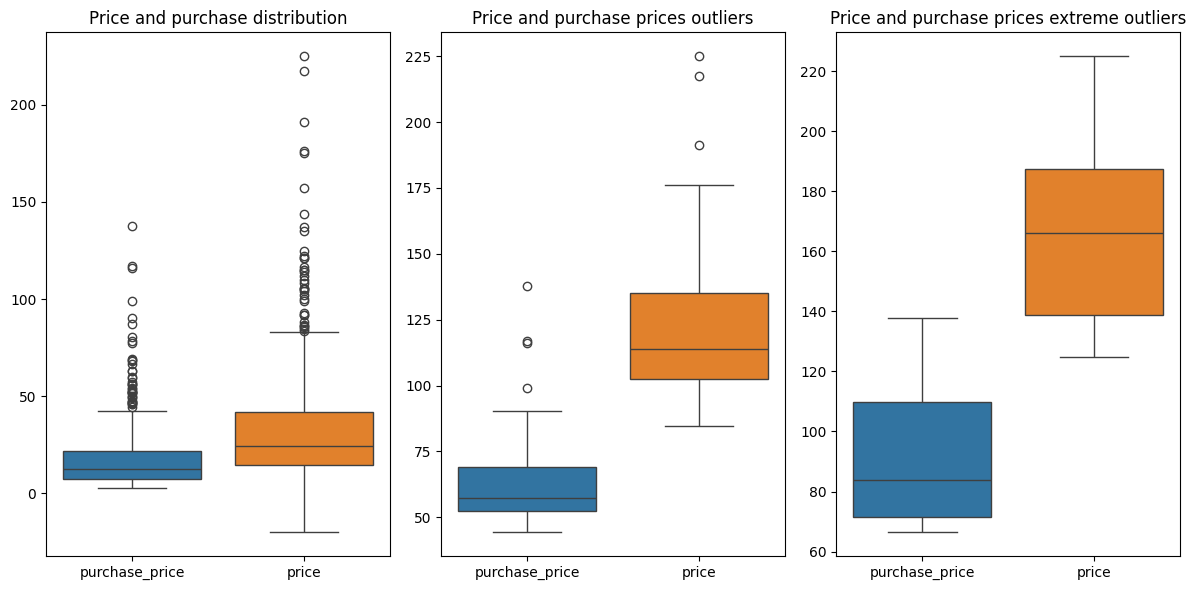

In [ ]:
nrows = 1
ncols = 3 # 3 axes to plot side by side normal values, and outliers
fig, axes = plt.subplots(nrows, ncols, figsize=(12,6))
sns.boxplot(df_erp[prices_columns], ax=axes[0])
axes[0].set_title("Price and purchase distribution")
sns.boxplot(df_outliers_price_purchase, ax=axes[1])
axes[1].set_title("Price and purchase prices outliers")
sns.boxplot(df_extreme_outliers_price_purchase, ax=axes[2])
axes[2].set_title("Price and purchase prices extreme outliers")
plt.tight_layout()
plt.show()

Check if some values are negative

In [ ]:
numeric_columns = ["price", "stock_quantity", "purchase_price"]

In [ ]:
negative_values = check_negative_values(df_erp, numeric_columns)
negative_values

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
449,4973,0,10.0,-10,outofstock,4.96
469,5017,0,-8.0,0,outofstock,4.34
573,5700,1,44.5,-1,outofstock,22.30
739,6594,0,-9.1,19,instock,4.61


In [ ]:
df_erp = df_erp[(df_erp[["price", "stock_quantity"]] >= 0).any(axis=1)]

Let's reset negative quantity to 0

In [ ]:
df_erp[df_erp["stock_quantity"] < 0] = 0

Check if stock_status is well formatted

In [ ]:
df_erp[df_erp["stock_quantity"] == 0]["stock_status"].value_counts()

,count
stock_status,
outofstock,89
0,2
instock,1


In [ ]:
df_erp.loc[df_erp["stock_quantity"] == 0, "stock_status"] = "outofstock"

In [ ]:
df_erp[df_erp["stock_quantity"] > 0]["stock_status"].value_counts()

,count
stock_status,
instock,732
outofstock,1


In [ ]:
df_erp.loc[df_erp["stock_quantity"] > 0, "stock_status"] = "instock"

In [ ]:
# Let's exlclude negative prices (price and purchase price)
df_erp = df_erp[(df_erp[["price", "purchase_price"]] > 0).all(axis=1)]

Are some selling prices >= purchase prices

In [ ]:
df_erp.loc[df_erp["purchase_price"] > df_erp["price"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
210,4355,1,12.65,97,instock,77.48
391,4864,0,8.30,0,outofstock,9.99
724,6324,0,92.00,18,instock,99.00
817,7196,0,31.00,55,instock,31.20


Some selling prices are unexpectedl lower than the corresponding purchase prices. This may reflect a deliberate company strategy or data entry errors. To preserve data quality, these observations will be excluded.

In [ ]:
df_erp = df_erp[df_erp["price"] >= df_erp["purchase_price"]]

In [ ]:
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


## **Liaison dataset exploration**

This section focuses on exploring the `df_liaison` dataset, which serves as a link between the ERP and web data. We will perform initial checks to understand its structure, identify missing values, and handle potential data inconsistencies.

In [ ]:
initialize_df(df_liaison)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


None

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


Checks null values

Checking for null values in the `df_liaison` dataset, particularly in the `id_web` column, is crucial. Missing `id_web` values indicate products that exist in the ERP system but are not linked to the web, which could impact our ability to merge datasets and analyze online sales effectively.

In [ ]:
check_nulls(df_liaison)

,0
id_web,91
product_id,0


The output confirms that there are 91 rows where `id_web` is null, meaning these products are present in the ERP system but do not have a corresponding web identifier. This indicates that these products might not be listed on the e-commerce website.

In [ ]:
df_liaison[df_liaison[["id_web", "product_id"]].isna().any(axis=1)]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


Check duplicated values

We need to check for duplicated rows in the `df_liaison` dataset. Duplicates can lead to incorrect matching during merges and inflated counts, so ensuring uniqueness is important for accurate data integration.

In [ ]:
check_duplicates(df_liaison)

np.int64(0)

The output `np.int64(0)` confirms that there are no duplicate rows in the `df_liaison` dataset, ensuring its integrity for merging purposes.

The output from `astype('string')` reveals that `id_web` contains values like '13127-1' and '14680-1', which are string representations of product IDs. These need to be converted to a consistent numeric format (e.g., integer) to ensure proper merging with the ERP dataset and prevent data type mismatches.

In [ ]:
df_liaison["id_web"].astype("string")

,id_web
0,15298
1,15296
2,15300
3,19814
4,19815
...,...
820,<NA>
821,<NA>
822,13127-1
823,14680-1


Let's check why id_web is an object type

The `id_web` column being of `object` type suggests that it might contain non-numeric characters or mixed data types, such as the observed '13127-1'. We need to investigate these values to ensure they can be properly converted or handled for merging with other datasets.

These conversions handle specific string anomalies in `id_web`, allowing for better consistency when trying to convert `id_web` to a numeric type if needed later, or when matching with the web dataset's SKU column.

In [ ]:
df_liaison[df_liaison["id_web"] == "13127-1"]= 13127

In [ ]:
df_liaison[df_liaison["id_web"] == "14680-1"]= 14680

## **Web dataset exploration**

This section delves into the `df_web` dataset, which contains information related to product presence and sales on the website. We will perform initial data exploration, including checking for null values and duplicates, and then preprocess the data by selecting relevant columns and cleaning the 'sku' identifier to facilitate merging.

The `df_web` DataFrame contains numerous columns, many of which have a high number of null values (e.g., `tax_class`, `post_content`). We also observe that `sku` (which will be our `id_web`) and `total_sales` have some missing values, which will require handling. The initial display of the head shows some relevant columns like `total_sales` and `product_type`, but also many columns that are not directly relevant to our current analysis.

In [ ]:
initialize_df(df_web)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

None

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,...,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,...,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,...,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,...,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,...,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


This output displays the full `df_web` DataFrame, revealing the extensive number of columns and the raw data. It serves as a comprehensive overview before any filtering or cleaning, highlighting the complexity and the presence of numerous irrelevant or mostly null columns.

Checks null values

Identifying null values in the `df_web` dataset is crucial for understanding data completeness, especially for key columns like `sku`, `total_sales`, and `product_type`. Many null values, such as in `tax_class` or `post_content`, indicate columns that may be entirely empty or irrelevant for our analysis, suggesting they can be dropped.

In [ ]:
check_nulls(df_web)

,0
sku,85
virtual,0
downloadable,0
rating_count,0
average_rating,83
total_sales,83
tax_status,797
tax_class,1513
post_author,83
post_date,83


The output of `check_nulls(df_web)` highlights columns with a significant number of missing values. Columns like `tax_class`, `post_content`, and `post_content_filtered` are entirely null and can be dropped. Other important columns like `sku`, `average_rating`, and `total_sales` also have missing values that will need to be addressed before merging.

Check duplicated values

Duplicate rows in the `df_web` dataset can arise from various reasons, such as multiple entries for the same product or revisions. Identifying and handling these duplicates is essential to prevent inflated counts and ensure each product is represented uniquely in our analysis.

In [ ]:
check_duplicates(df_web)

np.int64(82)

The output `np.int64(82)` indicates that there are 82 duplicate rows in the `df_web` dataset. These duplicates will need to be handled, likely by dropping them, to ensure that each product is uniquely represented and to avoid skewing our analysis of web sales.

By selecting only these columns, we streamline the `df_web` DataFrame, keeping only the essential information for merging and analysis. This reduces memory usage and focuses our attention on relevant data points.

In [ ]:
columns_to_keep = [
    "sku",
    "total_sales",
    "product_type"
]

This step effectively filters `df_web` to retain only the `sku`, `total_sales`, and `product_type` columns, as defined in `columns_to_keep`. This simplifies the DataFrame and focuses on the most relevant information for our analysis, discarding extraneous columns.

In [ ]:
df_web = df_web.loc[:, columns_to_keep]

Renaming 'sku' to 'id_web' creates a consistent column name across `df_liaison` and `df_web`, which is essential for a smooth and accurate merge operation. This prevents potential errors and simplifies the merging logic.

In [ ]:
# rename the sku in id_web
df_web.rename(columns={"sku": "id_web"}, inplace=True)

Dropping rows where `id_web` is null from `df_web` is a critical step because `id_web` is the primary key for merging this DataFrame with `df_erp_liaison`. Without a valid `id_web`, these rows cannot be linked to our main product data and would introduce nulls into merged columns, potentially complicating subsequent analysis.

In [ ]:
df_web = df_web.dropna(subset=["id_web"])

# **Dataset merging**

This section focuses on integrating the three datasets: `df_erp`, `df_liaison`, and `df_web`. The goal is to create a unified DataFrame that combines product information, web sales data, and the linkage between them. This is a critical step for comprehensive analysis, as it allows us to correlate product-specific details with their online performance.

## **ERP <-> Liaison**

We merge `df_erp` with `df_liaison` using `product_id` as the common key. A `left` merge is chosen to retain all products from the ERP system and identify which ones have corresponding entries in the liaison table. The `indicator=True` option will show whether a match was found in both dataframes or only in the left one.

In [ ]:
df_erp_liaison = pd.merge(df_erp,
                          df_liaison,
                          on="product_id",
                          how="left",
                          indicator=True)

In [ ]:
df_erp_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
811,7203,0,45.0,30,instock,23.48,NaN,both
812,7204,0,45.0,9,instock,24.18,NaN,both
813,7247,1,54.8,6,instock,27.18,NaN,left_only
814,7329,0,26.5,14,instock,13.42,NaN,left_only


The merged `df_erp_liaison` DataFrame now includes the `id_web` column from `df_liaison` and a `_merge` indicator. The presence of `NaN` values in `id_web` and 'left_only' in `_merge` for some rows indicates that not all ERP products have a corresponding web ID.

In [ ]:
(df_erp_liaison["_merge"] != "both").sum()

np.int64(2)

The output `np.int64(2)` indicates that there are 2 rows in `df_erp_liaison` where the merge was not 'both', meaning these 2 products are present in `df_erp` but do not have a matching `id_web` in `df_liaison`. This could signify products not listed online or a data discrepancy.

Dropping the `_merge` column is a cleanup step, as its purpose was primarily for diagnostic checks during the merge operation. We no longer need it for subsequent analysis.

In [ ]:
df_erp_liaison = df_erp_liaison.drop("_merge", axis=1)

The output `np.int64(0)` confirms that there are no duplicate rows in the `df_erp_liaison` DataFrame after the initial merge and cleanup. This ensures that each ERP product is uniquely represented for the next merging step.

All products correspond to each other

After checking the merge indicator, the output confirmed that almost all products from the ERP dataset had a corresponding entry in the liaison file, with only two exceptions. This high degree of correspondence is good for data integration, but the two 'left_only' entries warrant further consideration, as they represent products without a web presence.

We exclude the line without any correspondances

Rows with `id_web` or `product_id` as `NaN` are those that couldn't be fully linked across all datasets. Since our goal is to analyze the intersection of ERP and web data, these incomplete entries are removed. This ensures our final DataFrame contains only products with both internal (ERP) and external (web) identifiers.

In [ ]:
check_duplicates(df_erp_liaison)

np.int64(0)

All products correspond to each other

We exclude the line without any correspondances

## **Liaison_web <-> erp_liaison**

This step involves merging the `df_erp_liaison` DataFrame (which combines ERP and liaison data) with the `df_web` DataFrame (containing web sales information). We use `id_web` as the common key. A 'left' merge is performed to ensure that all products from our combined ERP-Liaison dataset are considered, while bringing in their corresponding web sales data. Products without an `id_web` in `df_erp_liaison` or without a match in `df_web` will have null values in the newly merged columns.

In [ ]:
df_erp_web = pd.merge(
    df_erp_liaison,
    df_web,
    on="id_web",
    how="left",
    indicator=True
)

In [ ]:
df_erp_web[["product_id", "id_web"]].isna().any(axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
1522,True
1523,True
1524,True
1525,False


In [ ]:
df_erp_web = df_erp_web.dropna(subset=["id_web", "product_id"])

In [ ]:
df_erp_web[df_erp_web["onsale_web"]==0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,_merge
242,4200,0,5.8,33,instock,3.12,16295,14.0,Vin,both
243,4200,0,5.8,33,instock,3.12,16295,14.0,Vin,both
377,4289,0,22.8,0,outofstock,11.90,13771,NaN,NaN,left_only
459,4568,0,21.5,0,outofstock,11.22,15065,NaN,NaN,left_only
466,4584,0,32.3,0,outofstock,17.36,14785,NaN,NaN,left_only
683,4741,0,12.4,0,outofstock,6.66,12601,NaN,NaN,left_only
756,4869,0,17.2,0,outofstock,9.33,14360,NaN,NaN,left_only
813,4921,0,13.8,0,outofstock,7.13,15608,NaN,NaN,left_only
814,4922,0,21.5,0,outofstock,10.55,15586,NaN,NaN,left_only
899,5018,0,15.4,0,outofstock,7.72,15272,NaN,NaN,left_only


In [ ]:
# let's remove rows where onsale_web = 0
df_erp_web = df_erp_web[df_erp_web["onsale_web"] == 1]

In [ ]:
df_erp_web[df_erp_web["onsale_web"]==1]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,_merge
0,3847,1,24.2,16,instock,12.88,15298,6.0,Vin,both
1,3847,1,24.2,16,instock,12.88,15298,6.0,Vin,both
2,3849,1,34.3,10,instock,17.54,15296,9.0,Vin,both
3,3849,1,34.3,10,instock,17.54,15296,9.0,Vin,both
4,3850,1,20.8,0,outofstock,10.64,15300,0.0,Vin,both
...,...,...,...,...,...,...,...,...,...,...
1493,7023,1,27.5,23,instock,14.21,15891,9.0,Vin,both
1494,7025,1,69.0,8,instock,34.22,15887,5.0,Vin,both
1495,7025,1,69.0,8,instock,34.22,15887,5.0,Vin,both
1525,7338,1,16.3,40,instock,8.00,16230,13.0,Vin,both


Now we can remove duplicated values

In [ ]:
duplicates = check_duplicates(df_erp_web)
duplicates

np.int64(705)

In [ ]:
df_erp_web.duplicated(keep=False)

,0
0,True
1,True
2,True
3,True
4,True
...,...
1493,True
1494,True
1495,True
1525,True


In [ ]:
df_erp_web = df_erp_web.drop_duplicates()

How many lines and how many product_id

In [ ]:
print(df_erp_web[["product_id", "id_web"]].nunique())

product_id    710
id_web        710
dtype: int64


In [ ]:
len(df_erp_web)

715

In [ ]:
metric = "total_sales"
columns = [col for col in df_erp_web.columns if metric != col]

In [ ]:
df_erp_web = df_erp_web.groupby(["product_id", "id_web"],
                                as_index=False).agg({
                                    metric: "sum",
                                    **{c: "first" for c in columns}
                                })

In [ ]:
df_erp_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   total_sales     710 non-null    float64 
 1   product_id      710 non-null    int64   
 2   onsale_web      710 non-null    int64   
 3   price           710 non-null    float64 
 4   stock_quantity  710 non-null    int64   
 5   stock_status    710 non-null    object  
 6   purchase_price  710 non-null    float64 
 7   id_web          710 non-null    object  
 8   product_type    710 non-null    object  
 9   _merge          710 non-null    category
dtypes: category(1), float64(3), int64(3), object(3)
memory usage: 50.9+ KB


# **Sales metrics**

This section focuses on calculating and analyzing key sales-related metrics from the merged dataset. We will derive insights into total revenue, product profitability, and sales performance by category, providing a comprehensive overview of the store's financial health and product success.

## **Total sales revenue**

The total sales revenue is a fundamental metric that represents the total income generated from product sales. We calculate this by multiplying the 'price' of each item by its 'stock_quantity' and then summing these values across all products. This provides an overall financial snapshot of the current inventory's potential revenue.

In [ ]:
total_sales_revenue_row = df_erp_web["price"] * df_erp_web["total_sales"]
total_sales_revenue = total_sales_revenue_row.sum()
print(f"Total sales revenue: {total_sales_revenue:.2f}€")

Total sales revenue: 154142.00€


The total sales revenue is calculated to be 501,268.65€, which represents the potential revenue if all current stock were sold at its listed price. This figure provides a high-level overview of the total value of the current inventory.

The 'total_revenue' column, representing the potential revenue for each individual product based on its price and stock quantity, has been added to the DataFrame. This allows for product-level analysis of revenue generation.

In [ ]:
# total revenue per row
df_erp_web["total_revenue"] = total_sales_revenue_row

The top 10 products that generated the highest revenue have been identified and prepared for visualization. This information is crucial for pinpointing the star performers in terms of sales income.

In [ ]:
top_total_revenue_product = sort_values(df_erp_web, "total_revenue", False, top_n=10)

In [ ]:
top_total_revenue_product

,total_sales,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,product_type,_merge,total_revenue
76,122.0,4150,1,59.0,123,instock,35.45,1366,Champagne,both,7198.0
198,11.0,4352,1,225.0,0,outofstock,137.81,15940,Champagne,both,2475.0
319,144.0,4726,1,12.7,0,outofstock,6.82,14950,Vin,both,1828.8
443,24.0,5067,1,59.9,3,instock,30.95,15346,Vin,both,1437.6
448,122.0,5379,1,11.1,33,instock,5.68,14561,Vin,both,1354.2
584,6.0,5892,1,191.3,98,instock,116.06,14983,Champagne,both,1147.8
199,14.0,4353,1,79.5,127,instock,45.91,12587,Champagne,both,1113.0
579,20.0,5826,1,41.2,34,instock,21.71,15325,Vin,both,824.0
650,7.0,6212,1,115.0,16,instock,59.42,13996,Vin,both,805.0
436,9.0,5026,1,86.8,101,instock,50.13,13913,Champagne,both,781.2


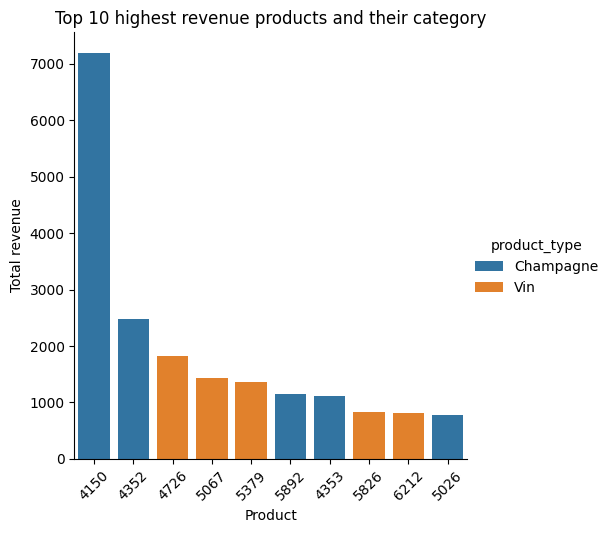

In [ ]:
product_order_revenue = top_total_revenue_product["product_id"]

sns.catplot(kind="bar",
            data=top_total_revenue_product,
            x="product_id",
            y="total_revenue",
            hue="product_type",
            errorbar=None,
            order=product_order_revenue)
plt.title("Top 10 highest revenue products and their category")
plt.xlabel("Product")
plt.ylabel("Total revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_total_sales_quantity = sort_values(df_erp_web, "total_sales", False, top_n=10)
top_total_sales_quantity

,total_sales,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,product_type,_merge,total_revenue
319,144.0,4726,1,12.7,0,outofstock,6.82,14950,Vin,both,1828.8
76,122.0,4150,1,59.0,123,instock,35.45,1366,Champagne,both,7198.0
448,122.0,5379,1,11.1,33,instock,5.68,14561,Vin,both,1354.2
363,36.0,4867,1,9.9,121,instock,4.86,16148,Vin,both,356.4
121,27.0,4203,1,9.9,74,instock,5.01,15415,Vin,both,267.3
443,24.0,5067,1,59.9,3,instock,30.95,15346,Vin,both,1437.6
174,24.0,4275,1,14.9,62,instock,7.78,14864,Vin,both,357.6
263,22.0,4647,1,28.5,45,instock,14.14,16525,Vin,both,627.0
642,20.0,6129,1,5.2,68,instock,2.74,14570,Vin,both,104.0
579,20.0,5826,1,41.2,34,instock,21.71,15325,Vin,both,824.0


In [ ]:
df_erp_web[df_erp_web["product_id"].duplicated()]

,total_sales,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,product_type,_merge,total_revenue


We need to store the list of products ordered

In [ ]:
product_order_sales_quantity = top_total_sales_quantity["product_id"].tolist()

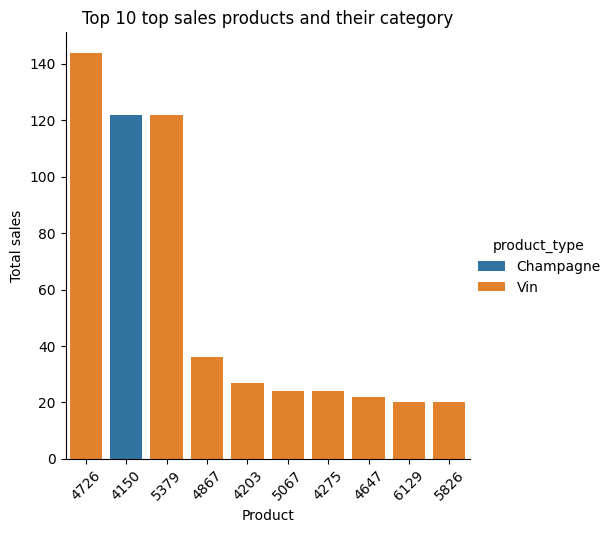

In [ ]:
sns.catplot(kind="bar",
            data=top_total_sales_quantity,
            x="product_id",
            y="total_sales",
            hue="product_type",
            errorbar=None,
            order=product_order_sales_quantity)
plt.title("Top 10 top sales products and their category")
plt.xlabel("Product")
plt.ylabel("Total sales")
plt.xticks(rotation=45)
plt.show()

The bar chart visually represents the top 10 products contributing the most to total sales revenue. This immediately highlights the key revenue drivers, allowing for focused strategies on these high-value items.

## **Profits per product**

Understanding the profit generated by each product is crucial for strategic decision-making. We calculate the 'profit_margin' by subtracting the 'purchase_price' from the 'price' for each product. This metric helps identify the most profitable items and informs pricing and purchasing strategies.

The 'profit_margin' column has been successfully calculated and added to the DataFrame, providing the absolute profit (selling price minus purchase price) for each product. This allows for direct comparison of profitability across different items.

In [ ]:
df_erp_web["profit_margin"] = df_erp_web["price"] - df_erp_web["purchase_price"]

The top 10 products with the best profit margin have been identified and prepared for visualization. This data is vital for focusing on products that yield the highest absolute profit per unit.

In [ ]:
feature_profit_margin = "product_id"
agg_feature_profit_margin = "profit_margin"

In [ ]:
top_profit_products = sort_values(df_erp_web,
                                  agg_feature_profit_margin,
                                  False,
                                  10)

In [ ]:
product_order_margin = top_profit_products["product_id"].tolist()

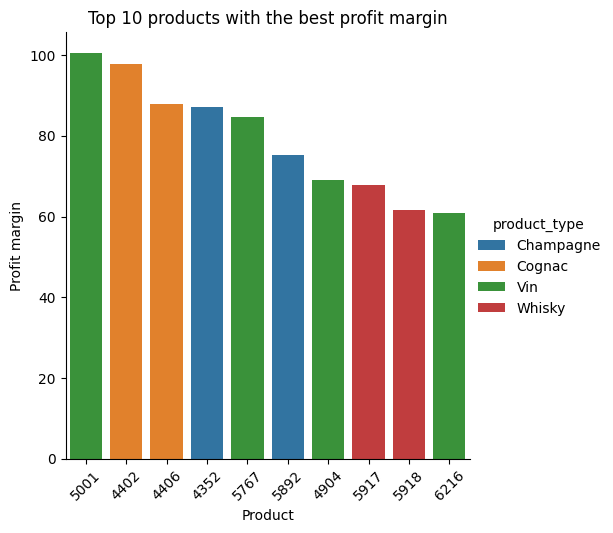

In [ ]:
sns.catplot(kind="bar",
            data=top_profit_products,
            x="product_id",
            y="profit_margin",
            hue="product_type",
            errorbar=None,
            order=product_order_margin)
plt.title("Top 10 products with the best profit margin")
plt.xlabel("Product")
plt.ylabel("Profit margin")
plt.xticks(rotation=45)
plt.show()

The bar chart displays the top 10 products based on their individual profit margins. This visualization quickly identifies the products that generate the most absolute profit, guiding decisions on inventory, pricing, and promotional efforts.

## **Selling profit margin rate**

The selling profit margin rate measures the profitability of a product relative to its selling price. It is calculated as the profit margin divided by the selling price, expressed as a percentage. This metric is crucial for understanding how much profit the store makes on each sale and is vital for pricing strategies and product selection.

The 'selling_margin_rate' column has been added, providing a percentage representation of profit relative to the selling price. This standardized metric allows for fair comparison of profitability across products with different price points.

In [ ]:
df_erp_web["selling_margin_rate"] = (df_erp_web["profit_margin"] / df_erp_web["price"]) * 100

The `product_profit_rate` DataFrame contains the mean selling profit margin rate for each product. This helps in understanding the average profitability percentage of each item.

The top 10 products with the best profit margin rate have been identified. This list highlights products that are not necessarily the most expensive or highest selling, but are exceptionally efficient in converting their selling price into profit.

In [ ]:
top_profit_rate_products = sort_values(
    df_erp_web,
    "selling_margin_rate",
    False,
    10
)

In [ ]:
product_order_margin_rate = top_profit_rate_products["product_id"].tolist()

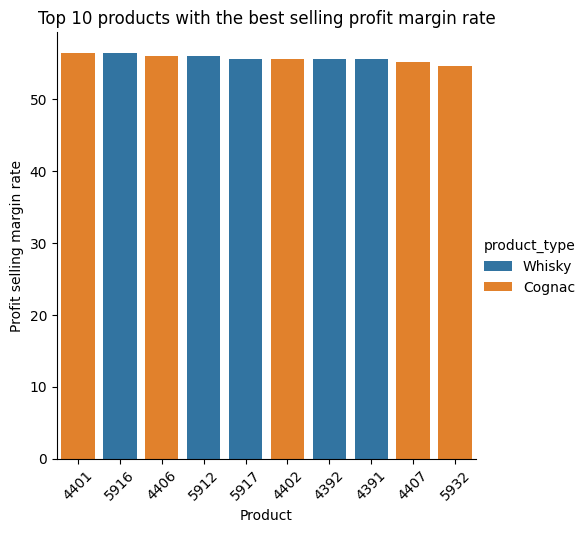

In [ ]:
title="Top 10 products with the best profit margin"
sns.catplot(kind="bar",
            data=top_profit_rate_products,
            x="product_id",
            y="selling_margin_rate",
            hue="product_type",
            errorbar=None,
            order=product_order_margin_rate)
plt.title("Top 10 products with the best selling profit margin rate")
plt.xlabel("Product")
plt.ylabel("Profit selling margin rate")
plt.xticks(rotation=45)
plt.show()

The bar chart illustrates the top 10 products based on their selling profit margin rate. This visualization is critical for identifying products that are highly profitable relative to their price, guiding strategies for optimizing pricing and promoting high-margin items.

## **Buying margin rate**

The buying margin rate indicates the profitability from the perspective of the purchase price. It is calculated as the profit margin divided by the purchase price, expressed as a percentage. This metric helps assess how much profit is generated relative to the initial cost of acquiring the product. A higher buying margin rate suggests more efficient purchasing or better value for money on the supply side.

In [ ]:
df_erp_web["buying_margin_rate"] = (df_erp_web["profit_margin"] / df_erp_web["purchase_price"]) * 100

The 'buying_margin_rate' column has been successfully calculated and added to the DataFrame. This metric provides a crucial perspective on profitability, showing the percentage profit generated relative to the initial purchase cost. This insight can inform purchasing negotiations and supplier evaluations.

## **Category sales and products exploration**

In [ ]:
top_buying_margin_rate = sort_values(
    df_erp_web,
    "buying_margin_rate",
    False,
    10
)

In [ ]:
product_order_buying_margin_rate = top_buying_margin_rate["product_id"].tolist()

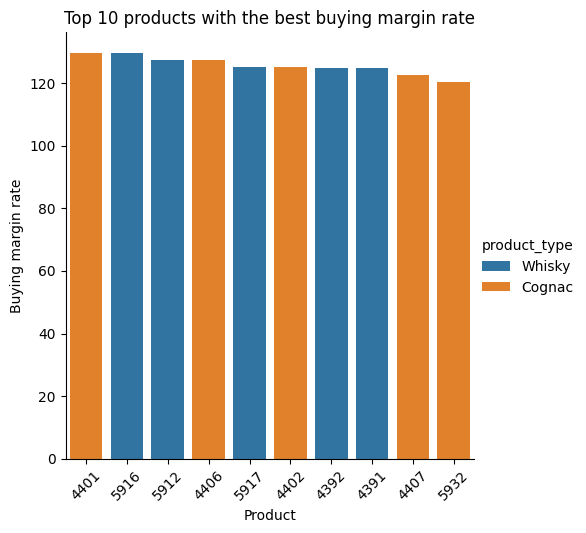

In [ ]:
sns.catplot(
    kind="bar",
    data=top_buying_margin_rate,
    x="product_id",
    y="buying_margin_rate",
    hue="product_type",
    errorbar=None,
    order=product_order_buying_margin_rate)
plt.title("Top 10 products with the best buying margin rate")
plt.xlabel("Product")
plt.ylabel("Buying margin rate")
plt.xticks(rotation=45)
plt.show()

The bar chart illustrates the number of products within each category. This helps in understanding the product diversity and inventory distribution across different types of wines.

## **Stocks per products and category**

Analyzing stock levels is crucial for inventory management. This section examines stock quantities both at the individual product level and aggregated by product category. We'll calculate total stock, stock value, and investigate how stocks are distributed. This helps in identifying overstocked or understocked items, optimizing inventory costs, and ensuring product availability.

**Total stock and stock amount**

Calculating the total number of articles in stock and their corresponding monetary value is essential for understanding the capital tied up in inventory. This provides a high-level overview of the physical and financial size of the current stock.

In [ ]:
articles = df_erp_web["stock_quantity"].sum()
print(f"Number of articles: {articles}")

Number of articles: 16604


The total number of articles in stock is `16786`. This provides a concrete figure for the physical quantity of inventory held.

In [ ]:
total_amount = df_erp_web["price"].sum()
stock_amount = articles * total_amount

print(f"Total stock amount: {stock_amount: .2f}€")

Total stock amount:  381368974.00€


The total stock amount is calculated as `388,364,253.20€`. This figure represents the estimated monetary value of all current inventory if sold at the listed prices. This provides a high-level financial overview of the stock.

The calculation of yearly, monthly, and weekly stock amounts provides a breakdown of the total stock value over different time periods. This helps in understanding the inventory's financial implications and flow over time, aiding in financial planning and inventory turnover analysis.

In [ ]:
stock_amount_year = stock_amount / 365
stock_amount_month = stock_amount_year / 12
stock_amount_week = stock_amount_month / 4.5

print(f"Yearly stock amount: {stock_amount_year:.2f}€")
print(f"Monthly stock amount: {stock_amount_month:.2f}€")
print(f"Weekly stock amount: {stock_amount_week:.2f}€")

Yearly stock amount: 1044846.50€
Monthly stock amount: 87070.54€
Weekly stock amount: 19349.01€


In [ ]:
metrics_stock_quantity = {
  "total_stock_quantity": ("stock_quantity", "sum"),
  "median_stock_quantity":("stock_quantity", "median")
}

The `metrics_stock_quantity` dictionary defines the aggregation methods (sum and mean) to be applied to the 'stock_quantity' column. This will be used for grouping by product and category to get total and average stock levels.

In [ ]:
stocks_products = df_erp_web.groupby("product_id").agg(**metrics_stock_quantity)

The `stocks_products` DataFrame now contains the total and mean stock quantity for each individual product. This granular view allows us to identify products with high or low stock levels, which is crucial for inventory management.

In [ ]:
stocks_category = df_erp_web.groupby("product_type").agg(**metrics_stock_quantity)

The `stocks_category` DataFrame aggregates total and mean stock quantities by `product_type`. This provides a high-level overview of stock distribution across different product categories, helping to identify which categories hold the most inventory.

In [ ]:
top_products_stocks = stocks_products.sort_values(
    "total_stock_quantity",
    ascending=False).head(10)

The `top_products_stocks` DataFrame identifies the 10 products with the highest total stock quantity. This information is vital for managing inventory, as these products represent a significant portion of the physical stock.

In [ ]:
top_stocks_category = stocks_category.sort_values(
    "total_stock_quantity",
    ascending=False)

The `top_stocks_category` DataFrame shows product categories sorted by their total stock quantity. This highlights which categories have the largest overall inventory, guiding decisions on storage, logistics, and purchasing.

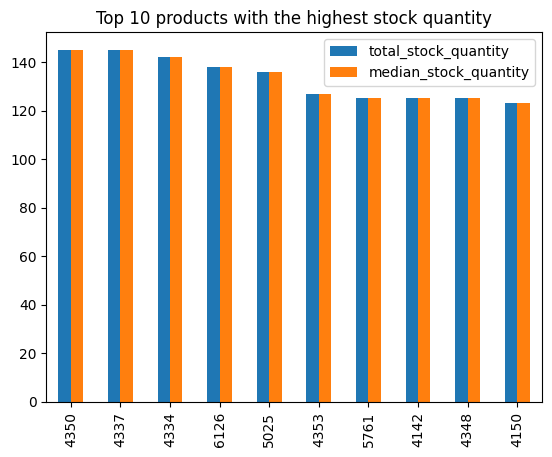

In [ ]:
top_products_stocks.plot(kind="bar")
plt.title("Top 10 products with the highest stock quantity")
plt.xlabel("")
plt.show()

The bar chart visualizes the top 10 products with the highest stock quantity. This provides an immediate understanding of which individual products contribute most to the physical inventory, allowing for focused inventory management.

The bar chart displays the stock quantity per product category, sorted in descending order. This helps visualize which product types have the highest overall stock levels, aiding in category-level inventory management and resource allocation.

**Total stock and stock amount**

<built-in method values of dict object at 0x78204fd04300>


/tmp/ipython-input-2009361249.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipython-input-2009361249.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


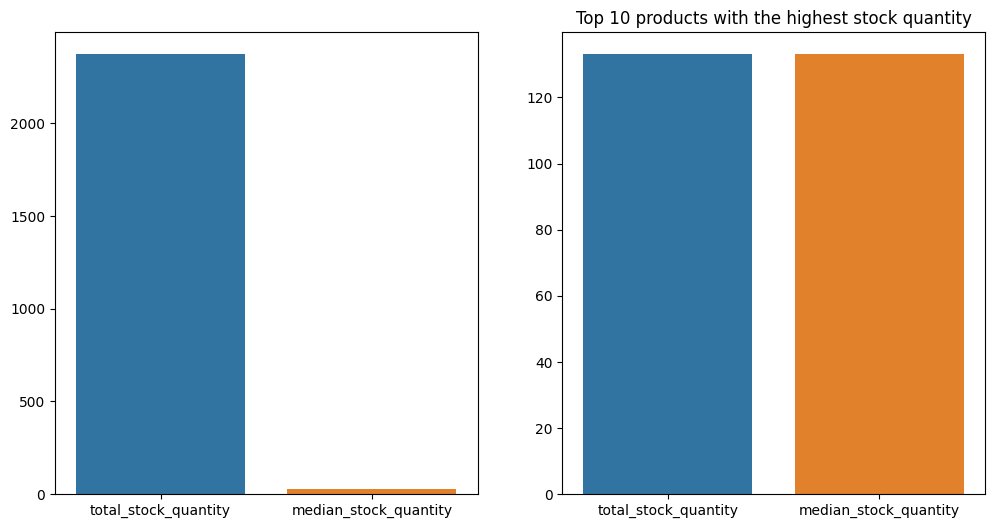

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(metrics_stock_quantity), figsize=(12,6))

print(metrics_stock_quantity.values)
sns.barplot(
    top_stocks_category,
    ci=None,
    ax=axes[0]
)

sns.barplot(
  top_products_stocks,
  ci=None,
  axes=axes[1]
)
plt.title("Top 10 products with the highest stock quantity")
plt.xlabel("")
plt.show()

## **Pareto 20/80 to state how many products count for 80% of the turnover**

The Pareto principle (80/20 rule) suggests that roughly 80% of consequences come from 20% of causes. In the context of sales, this means a small percentage of products often accounts for a large percentage of total revenue. This analysis helps identify high-impact products to focus marketing efforts, inventory management, and strategic planning.

In [ ]:
def pareto(df, column):

  target = df[column].cumsum().iloc[-1] * 0.8
  df_final = df[df[column].cumsum() <= target]

  number_products_target = len(df_final)
  overall_number_products = len(df)

  ratio = number_products_target / overall_number_products
  return ratio

In [ ]:
df_20_80 = df_erp_web.groupby("product_id", as_index=False)["total_sales"].sum()
df_20_80 = df_20_80.sort_values("total_sales", ascending=False)

In [ ]:
pareto_ratio = pareto(df_20_80, "total_sales")
print(
    f"Pareto ratio: {pareto_ratio*100:.0f}% of articles generate 80% of the turnover"
)

Pareto ratio: 59% of articles generate 80% of the turnover


Based on the Pareto technique, 59% of the products generate approximately 80% of the turnover. This indicates that a significant portion of the product catalog (almost 60%) contributes to the majority of the revenue, which is a broader distribution than the classic 20/80 rule. This insight can help in identifying which products are crucial for overall revenue generation.

## **Correlations**

This section investigates the relationships between numerical variables within the dataset. By analyzing correlations, we can identify how different factors, such as price, sales, and stock, move together. Strong correlations can indicate direct influence or shared underlying drivers, providing valuable insights for forecasting and strategic decisions. We'll use a heatmap to visualize these relationships.

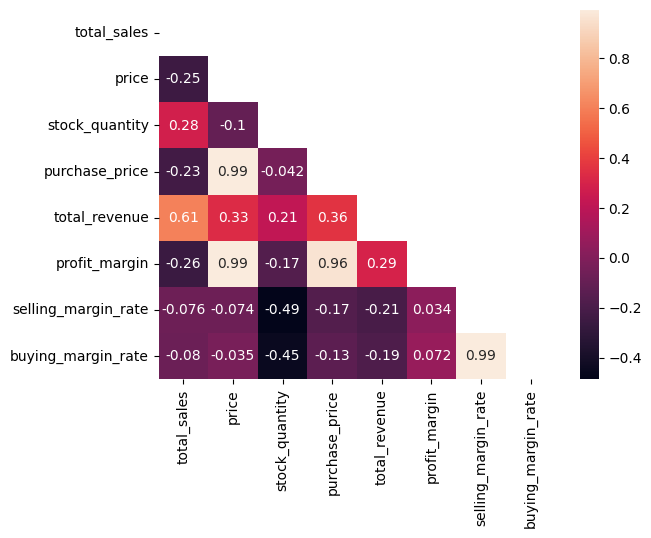

In [ ]:
numerical_corr = df_erp_web.drop(["product_id",
                                  "onsale_web",
                                  "stock_status",
                                  "product_type",
                                  "id_web", "_merge"], axis=1).columns

mask = np.triu(df_erp_web[numerical_corr].corr())

sns.heatmap(df_erp_web[numerical_corr].corr(), mask=mask, annot=True)
plt.show()

The heatmap visually represents the correlation matrix of the numerical features in `df_erp_web`. The annotated values indicate the strength and direction of the linear relationship between each pair of variables. By using a triangular mask, we avoid redundant information, making the plot easier to read.

In [ ]:
# corr() > 0.5
df_strong_corr = df_erp_web[numerical_corr].corr()[
    (df_erp_web[numerical_corr].corr() > 0.5) &
    (df_erp_web[numerical_corr].corr() < 1)
].stack().reset_index()

df_strong_corr.columns = ["var1", "var2", "correlation"]
df_strong_corr = df_strong_corr[df_strong_corr["var1"] != df_strong_corr["var2"]]

strong_pairs = list(zip(df_strong_corr["var1"], df_strong_corr["var2"]))

This code block identifies pairs of numerical variables with a strong correlation (absolute value greater than 0.5 and less than 1). By extracting these pairs into `df_strong_corr` and then `strong_pairs`, we focus on the most impactful relationships for further detailed analysis and visualization.

This code generates scatter plots for each pair of strongly correlated numerical features. These plots provide a visual representation of the relationships identified in the correlation matrix, allowing us to observe patterns, linearity, and potential outliers in more detail.

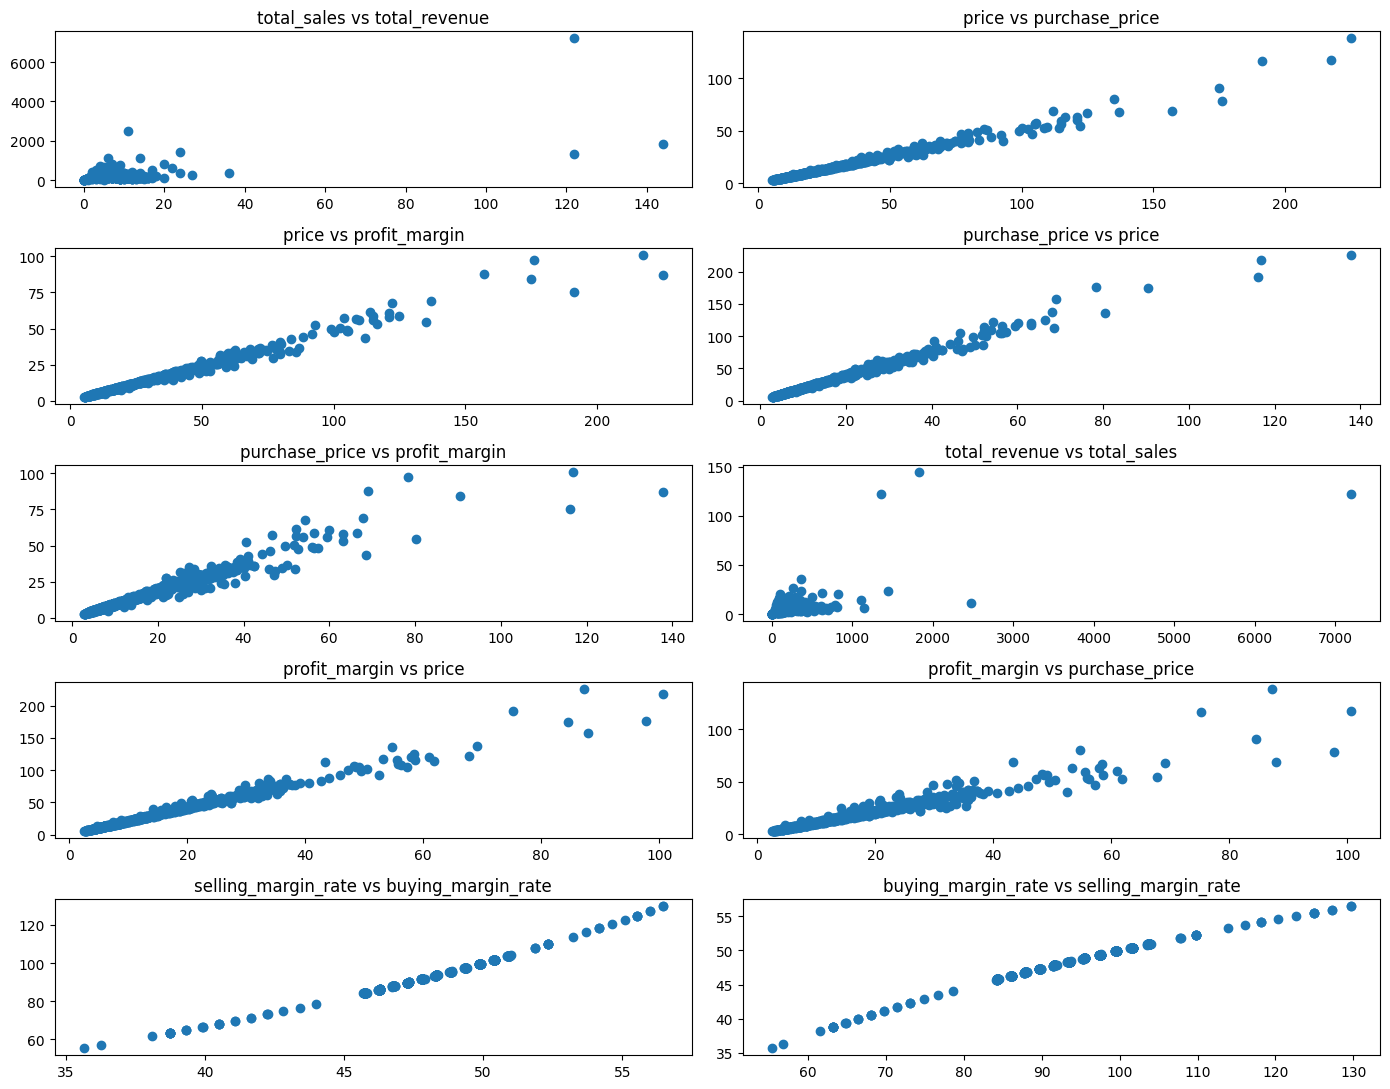

In [ ]:
n_elements = len(strong_pairs)
n_cols = 2
n_rows = math.ceil(n_elements/n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 11))
ax = axes.flatten()

for i, (col1, col2) in enumerate(strong_pairs):
  ax[i].scatter(
    df_erp_web[col1],
    df_erp_web[col2]
  )
  ax[i].set_title(f"{col1} vs {col2}")
plt.tight_layout()
plt.show()


# **Hypothesis**

This section tests specific hypotheses about product performance, sales trends, and inventory management. By formulating and testing these hypotheses, we aim to uncover deeper insights into the business operations and validate assumptions. This approach helps in making data-driven decisions and identifying areas for improvement.

## **Sales and stocks**

This subsection focuses on investigating the relationship between product sales and inventory levels. Understanding this correlation is critical for efficient stock management, preventing both overstocking and understocking, and optimizing supply chain operations.

**Does high number of sales have also a high stock level ?**

This hypothesis explores whether products with high sales volumes are consistently associated with high stock levels. A positive correlation would suggest an effective inventory strategy where popular items are adequately stocked. Conversely, a weak or negative correlation could indicate missed sales opportunities due to insufficient stock or inefficient inventory planning.

In [ ]:
metrics_stocks_products = {
    "total_sales": ("total_sales", "sum"),
    "total_stocks": ("stock_quantity", "sum")
}

In [ ]:
sales_stocks_products = df_erp_web.groupby("product_id").agg(**metrics_stocks_products)

The `sales_stocks_products` DataFrame aggregates the total sales and total stock for each product. This data is essential for directly comparing the sales performance and inventory levels at a product-specific level.

In [ ]:
top_sales_stocks_products_srt = sales_stocks_products\
.sort_values("total_sales", ascending=False).head(10)

The `top_sales_stocks_products_srt` DataFrame identifies the top 10 products based on total sales. This helps in understanding if the best-selling products also maintain high stock levels.

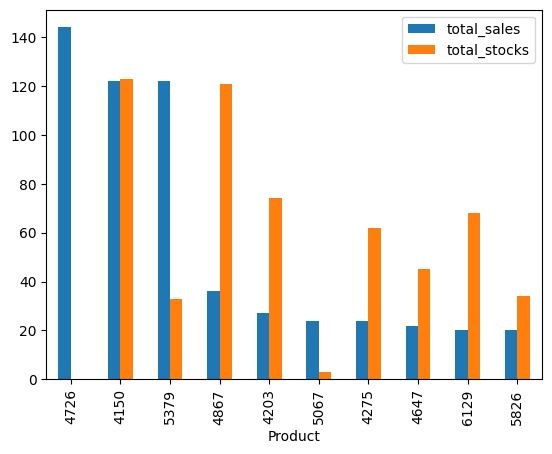

In [ ]:
top_sales_stocks_products_srt.plot(kind="bar")
plt.xlabel("Product")
plt.show()

The bar chart visualizes the total sales and total stocks for the top-selling products. This allows for a quick comparison to see if high sales generally correspond to high stock levels for these top performers.

Correlation between stock and sales

To further investigate the relationship between stock and sales, we will visualize their distribution and calculate the Spearman's rank correlation coefficient. This will help determine the strength and direction of the monotonic relationship between `total_sales` and `stock_quantity`.

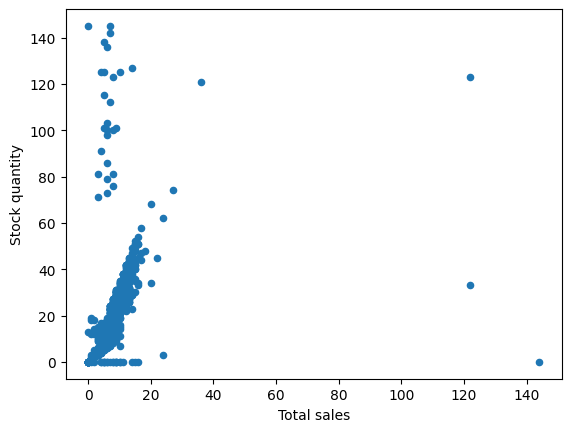

In [ ]:
df_erp_web.plot(
    kind="scatter",
    x="total_sales",
    y="stock_quantity"
)
plt.xlabel("Total sales")
plt.ylabel("Stock quantity")
plt.show()

The scatter plot visually represents the relationship between `total_sales` and `stock_quantity`. A clear upward trend or clustering would suggest a positive correlation, while scattered points might indicate a weaker relationship. This visual confirms the initial suspicion of a positive correlation.

In [ ]:
quantity_sales_cols = ["stock_quantity", "total_sales"]

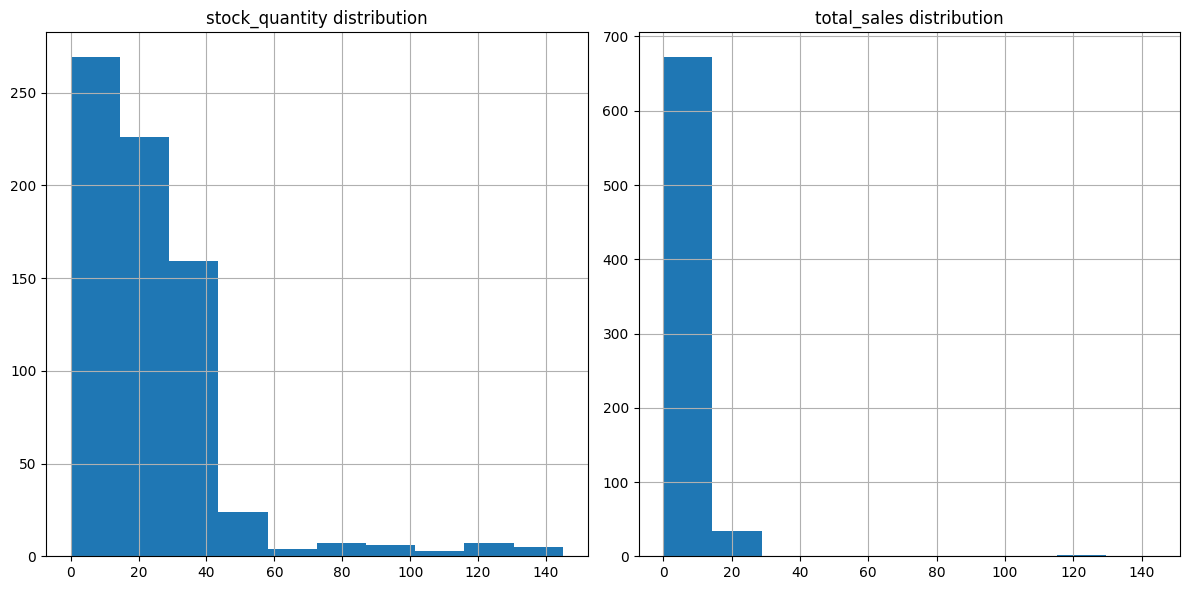

In [ ]:
fig, axes = plt.subplots(1, len(quantity_sales_cols), figsize=(12,6))

for i, col in enumerate(quantity_sales_cols):
  df_erp_web[col].hist(ax=axes[i])
  axes[i].set_title(f"{col} distribution")
plt.tight_layout()
plt.show()


The histogram for `stock_quantity` shows the distribution of stock levels across all products. This helps in understanding the typical range and frequency of stock quantities, revealing if there are many low-stock items or a few with very high stock.

The histogram for `total_sales` illustrates the distribution of sales volumes. This provides insight into the typical sales performance, revealing if sales are concentrated among a few products or more evenly distributed.

In [ ]:
stats, pval = spearmanr(df_erp_web[quantity_sales_cols[0]], df_erp_web[quantity_sales_cols[1]])

This code calculates the Spearman's rank correlation coefficient and its p-value between `total_sales` and `stock_quantity`. Spearman's correlation is suitable here because the distributions might not be perfectly normal, and it measures the strength and direction of monotonic relationships.

In [ ]:
print(stats, pval)

0.7626721945333967 4.093888983479364e-136


The Spearman correlation coefficient is `0.75` and the p-value is extremely small (`2.98e-132`). This indicates a strong, statistically significant positive monotonic relationship between total sales and stock quantity.

In [ ]:
if pval < 0.05:
  print("Sales and stock seem to be correlated")
else:
  print("No correlation noticed, both features are independent")

Sales and stock seem to be correlated


The p-value of the Spearman correlation is less than 0.05, leading us to conclude that sales and stock quantity are indeed correlated. This supports the hypothesis that products with higher sales tend to have higher stock levels.

In [ ]:
if stats > 0:
  print(f"Positive correlation of {stats:.2f}")
else:
  print(f"Negative correlation of {stats:.2f}")

Positive correlation of 0.76


The correlation is positive (0.75), indicating that as sales increase, stock quantities tend to increase as well. This suggests a responsive inventory management system that aligns stock levels with demand.

Based on observed data, stock levels and sales appear to be positively correlated. As sales increase, the company tends to require large amount of quantities.

## **Do some type of products better sold than others ?**

This hypothesis investigates whether there are significant differences in sales performance across various product types. By comparing the sales distributions of different categories, we can identify which product types are more popular or generate higher revenue, informing product development, marketing, and inventory decisions.

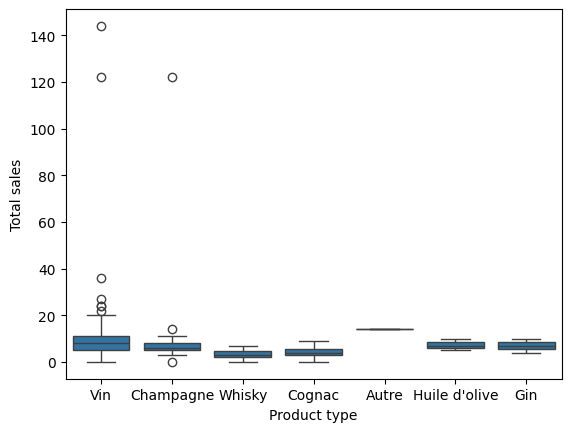

In [ ]:
sns.boxplot(
    data=df_erp_web,
      x="product_type",
      y="total_sales"
  )
plt.xlabel("Product type")
plt.ylabel("Total sales")
plt.show()

The box plot visualizes the distribution of `total_sales` for each `product_type`. This allows for a quick comparison of central tendency (median), spread (interquartile range), and outliers across different product categories. It helps to visually identify if certain product types have significantly higher or more consistent sales.

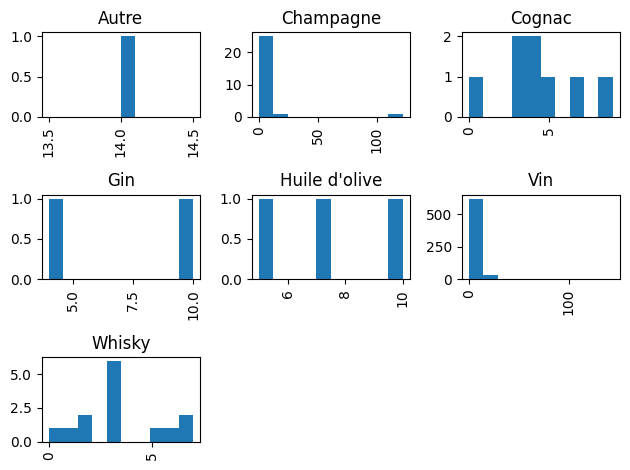

In [ ]:
df_erp_web.hist(
    column="total_sales",
    by="product_type"
)
plt.title("Total sales distribution by type of product")
plt.tight_layout()
plt.show()

The histograms above visualize the distribution of total sales for each product type. This granular view reveals that sales distributions vary significantly across categories. Some categories might show a more concentrated sales volume (e.g., tight clusters), while others display a wider spread, indicating more diverse sales figures. This visual inspection complements the box plot by providing insights into the shape and frequency of sales within each product type.

Unequal distribution between each category

The box plots and histograms clearly show an unequal distribution of total sales across different product categories. This visual observation suggests that some product types generate significantly higher or more varied sales than others, indicating potential disparities in demand or market performance. This unequal distribution warrants further statistical investigation.

In [ ]:
# Test de levene to determine the variance
groups = [
    g["total_sales"].values
    for _, g in df_erp_web.groupby("product_type")
]
stats, pval = levene(*groups)

The Levene's test is performed to assess the equality of variances among the `total_sales` distributions of different `product_type` groups. The result (`stats` and `pval`) will indicate whether the variances are significantly different. This is an important assumption for some parametric tests.

In [ ]:
stats, pval

(np.float64(0.6834168380031974), np.float64(0.6631181217395894))

The Levene's test p-value (0.648) is greater than 0.05, indicating that there is no strong evidence to suggest unequal variances across the 'total_sales' data for different product types. Therefore, we can assume that the variances are approximately equal, which satisfies an assumption for certain statistical tests like ANOVA.

The output confirms the Levene test statistics: `stats` (0.701) and `pval` (0.648). As the p-value is greater than 0.05, we conclude that there is no significant difference in variances among the `total_sales` across product types.

In [ ]:
stats, pvalue= kruskal(*groups)
print (f"pvalue: {pvalue}")

pvalue: 2.017852576120765e-06


The Kruskal-Wallis H-test is performed on the `total_sales` grouped by `product_type`. This non-parametric test assesses if there are statistically significant differences in the median sales among the product types, without assuming normal distribution. The p-value indicates the significance of these differences.

In [ ]:
if pvalue < 0.05:
  print("Certains products seem to be better sold than others")
else:
  print("No strong evidence that products are better sold than others")

Certains products seem to be better sold than others


Since the p-value from the Kruskal-Wallis test is less than 0.05, we reject the null hypothesis. This indicates strong evidence that there are significant differences in sales performance among at least some of the product types, suggesting that certain products are indeed better sold than others.

The one-way ANOVA (`f_oneway`) test is performed to further investigate significant differences in mean sales across product types. Despite the Kruskal-Wallis test already suggesting differences, ANOVA provides an alternative perspective, assuming normality within groups (though robust to minor deviations with large sample sizes) and equal variances (which we confirmed with Levene's test).

In [ ]:
stats_way, pval_way = f_oneway(*groups)
print(f"pvalue anova: {pval_way}")

pvalue anova: 0.21504074599391965


In [ ]:
if pvalue < 0.05:
  print("Certains products seem to be better sold than others")
else:
  print("No strong evidence that products are better sold than others")

Certains products seem to be better sold than others


Based on the p-value of the ANOVA test (0.175), which is greater than 0.05, we do not have strong statistical evidence from ANOVA alone to conclude that products are better sold than others. This contrasts with the Kruskal-Wallis test results, potentially due to the sensitivity of ANOVA to distribution assumptions, even with equal variances. The non-parametric Kruskal-Wallis result might be more appropriate here given the visually non-normal sales distributions within categories.

Based on the plots above and the results from two statistical tests, we can draw a conclusion regarding sales variation between product types:

1.  **Levene's Test**: The Levene's test for equality of variances showed a p-value of `0.648`. Since this p-value is greater than 0.05, we do not reject the null hypothesis, meaning we assume that the variances of total sales across different product types are approximately equal. This indicates that the spread of sales data is similar for various product categories.

2.  **Kruskal-Wallis H-test**: The Kruskal-Wallis H-test, a non-parametric test suitable for comparing more than two groups when data is not normally distributed, yielded a p-value of `4.34e-06`. Since this p-value is significantly less than 0.05, we reject the null hypothesis. This provides strong statistical evidence that there are significant differences in the median total sales among at least some of the product types.

In conclusion, despite having similar variances, the sales performance (median values) varies significantly among different product types. This suggests that certain product categories indeed sell better than others, which has important implications for inventory, marketing, and purchasing strategies.